In [1]:
import mysql.connector
import pandas as pd

host = "212.227.148.202"
user = "Equipo32"
password = "E1q2u3i4p5o32"
db = "Equip_32"

connection = mysql.connector.connect(
    host=host,
    user=user,
    password=password,
    database=db
)

if connection.is_connected():
    print("Conexión exitosa")

query = """
SELECT *
FROM BANK_marketing;
"""

df = pd.read_sql(query, connection)

df.head()

Conexión exitosa


/var/folders/6f/lhr87vh51bq38sm9v46389m00000gn/T/ipykernel_5459/1945725332.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
df.shape

(10642, 18)

In [3]:
df.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'deposit'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10642 entries, 0 to 10641
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10642 non-null  int64  
 1   age        10633 non-null  float64
 2   job        10642 non-null  str    
 3   marital    10637 non-null  str    
 4   education  10635 non-null  str    
 5   default    10642 non-null  str    
 6   balance    10642 non-null  int64  
 7   housing    10642 non-null  str    
 8   loan       10642 non-null  str    
 9   contact    10642 non-null  str    
 10  day        10642 non-null  int64  
 11  month      10642 non-null  str    
 12  duration   10642 non-null  int64  
 13  campaign   10642 non-null  int64  
 14  pdays      10642 non-null  int64  
 15  previous   10642 non-null  int64  
 16  poutcome   10642 non-null  str    
 17  deposit    10642 non-null  str    
dtypes: float64(1), int64(7), str(10)
memory usage: 1.5 MB


In [5]:
connection.close()

In [6]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing[missing["missing_count"] > 0]

,missing_count,missing_percent
age,9,0.08
marital,5,0.05
education,7,0.07


In [7]:
# ver que filas tienen nulos
df[df.isna().any(axis=1)]

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
1088,1089,53.0,management,NaN,secondary,no,1004,no,yes,telephone,22,dec,119,1,-1,0,unknown,yes
1181,1182,NaN,management,married,tertiary,no,309,yes,no,cellular,5,feb,676,1,-1,0,unknown,yes
1300,1301,37.0,technician,married,NaN,no,549,no,no,cellular,2,mar,239,1,-1,0,unknown,yes
1410,1411,NaN,blue-collar,married,primary,no,4979,no,no,telephone,6,apr,180,1,-1,0,unknown,yes
2943,2944,24.0,student,single,NaN,no,382,no,no,cellular,13,nov,256,2,92,3,failure,yes
3719,3720,68.0,retired,NaN,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
4019,4020,NaN,services,single,secondary,no,1934,no,no,cellular,29,sep,271,1,-1,0,unknown,yes
4737,4738,37.0,management,single,NaN,no,102,yes,no,cellular,6,may,445,1,258,2,failure,yes
4854,4855,34.0,management,NaN,tertiary,no,5,no,no,cellular,18,aug,370,2,-1,0,unknown,yes
5680,5681,NaN,technician,single,tertiary,no,720,no,no,cellular,12,aug,234,4,-1,0,unknown,no


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["id"].duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,10642.000000,10633.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000
mean,5321.500000,41.252610,1536.614828,15.645461,378.693197,2.496147,52.073670,0.851344
std,3072.225117,12.003015,3223.419300,8.432874,351.180910,2.694660,109.208889,2.321755
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,2661.250000,32.000000,127.000000,8.000000,141.000000,1.000000,-1.000000,0.000000
50%,5321.500000,39.000000,558.000000,15.000000,260.000000,2.000000,-1.000000,0.000000
75%,7981.750000,49.000000,1728.750000,22.000000,510.000000,3.000000,57.750000,1.000000
max,10642.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [11]:
df["deposit"].value_counts()

deposit
no     5353
yes    5289
Name: count, dtype: int64

In [12]:
df.describe(include="all")

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,10642.000000,10633.000000,10642,10637,10635,10642,10642.000000,10642,10642,10642,10642.000000,10642,10642.000000,10642.000000,10642.000000,10642.000000,10642,10642
unique,NaN,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,NaN,2447,6030,5216,10487,NaN,5660,9270,7707,NaN,2646,NaN,NaN,NaN,NaN,7885,5353
mean,5321.500000,41.252610,NaN,NaN,NaN,NaN,1536.614828,NaN,NaN,NaN,15.645461,NaN,378.693197,2.496147,52.073670,0.851344,NaN,NaN
std,3072.225117,12.003015,NaN,NaN,NaN,NaN,3223.419300,NaN,NaN,NaN,8.432874,NaN,351.180910,2.694660,109.208889,2.321755,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,2661.250000,32.000000,NaN,NaN,NaN,NaN,127.000000,NaN,NaN,NaN,8.000000,NaN,141.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,5321.500000,39.000000,NaN,NaN,NaN,NaN,558.000000,NaN,NaN,NaN,15.000000,NaN,260.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,7981.750000,49.000000,NaN,NaN,NaN,NaN,1728.750000,NaN,NaN,NaN,22.000000,NaN,510.000000,3.000000,57.750000,1.000000,NaN,NaN


In [13]:
categoricas = df.select_dtypes(include="object").columns

for col in categoricas:
    print()
    print(df[col].value_counts())


job
management       2447
blue-collar      1830
technician       1737
admin.           1279
services          881
retired           755
self-employed     388
student           354
unemployed        338
entrepreneur      308
housemaid         257
unknown            68
Name: count, dtype: int64

marital
married     6030
single      3374
divorced    1233
Name: count, dtype: int64

education
secondary    5216
tertiary     3527
primary      1419
unknown       473
Name: count, dtype: int64

default
no     10487
yes      155
Name: count, dtype: int64

housing
no     5660
yes    4982
Name: count, dtype: int64

loan
no     9270
yes    1372
Name: count, dtype: int64

contact
cellular     7707
unknown      2196
telephone     739
Name: count, dtype: int64

month
may    2646
aug    1450
jul    1429
jun    1174
nov     898
apr     888
feb     746
oct     387
jan     327
sep     314
mar     274
dec     109
Name: count, dtype: int64

poutcome
unknown    7885
failure    1180
success    1065
other     

/var/folders/6f/lhr87vh51bq38sm9v46389m00000gn/T/ipykernel_5459/3651939843.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include="object").columns


Matplotlib is building the font cache; this may take a moment.


array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>],
       [<Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>, <Axes: >]], dtype=object)

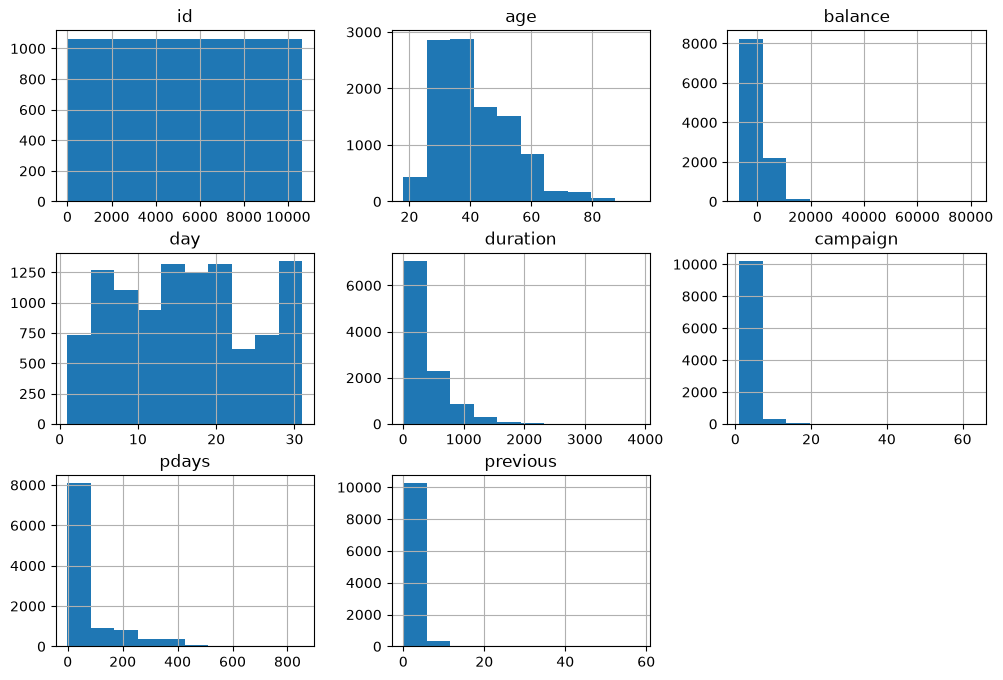

In [14]:
df.hist(figsize=(12,8))

In [15]:
df.corr(numeric_only=True)

,id,age,balance,day,duration,campaign,pdays,previous
id,1.000000,-0.018351,-0.052083,0.042937,-0.459804,0.101147,-0.066993,-0.060385
age,-0.018351,1.000000,0.113850,0.000448,-0.001459,-0.006937,0.003492,0.021585
balance,-0.052083,0.113850,1.000000,0.010562,0.021708,-0.011664,0.020407,0.032856
day,0.042937,0.000448,0.010562,1.000000,-0.018101,0.131814,-0.074064,-0.057324
duration,-0.459804,-0.001459,0.021708,-0.018101,1.000000,-0.037750,-0.028958,-0.029033
campaign,0.101147,-0.006937,-0.011664,0.131814,-0.037750,1.000000,-0.103519,-0.050652
pdays,-0.066993,0.003492,0.020407,-0.074064,-0.028958,-0.103519,1.000000,0.504004
previous,-0.060385,0.021585,0.032856,-0.057324,-0.029033,-0.050652,0.504004,1.000000
